## Set Up

In [1]:
#source TFAvenv/bin/activate (launching and exiting the virtual environment containing the required modules, stored in the working directory)
#TFAvenv/bin/python your_script.py - for running a script in the virtual environment
#source deactivate

#import all the libraries needed
from import_dep import *

# import my functions stored in the file 'functions' which can then be called with functions.function_name()
from ttw_functions import *
from ttw import ttw
from ttw_models import * # Import new modularized models
from ttw_models import run_xrd_fitting, find_peak

# import custom plot style and colorbar functions
from plot_style import set_plot_style, add_colorbar, generate_colormaps_and_normalizers


# Define the path to the root directory containing all the XRD data
root_XRD = '/Users/horatiocox/Desktop/RUG_Postdoc/Experiments/XRD'


### Plotting and Output Variables 
export_data = True # set to True to export the data to a powerpoint presentation and as svg files and export to path_out
fig_format = 'png' # format of the figure to be saved

powerpoint_string = 'EM011' # string to be added to the powerpoint file name

plot_transparency = True # set to True to make the data plots transparent


# Custom Scence style settings for figures
fig_size = set_plot_style(export_data = export_data, use_tex=True)
#plt.style.use(['science', 'grid', 'nature'])

## Import Data

In [2]:
#ttw_JT071 = ttw(root_XRD, folder_name = 'JT071')
ttw_JT082 = ttw(root_XRD, folder_name = 'JT082')
ttw_JT090 = ttw(root_XRD, folder_name = 'JT090')

ttw_HC007 = ttw(root_XRD, folder_name = 'HC007')
ttw_HC011 = ttw(root_XRD, folder_name = 'HC011')
ttw_HC013 = ttw(root_XRD, folder_name = 'HC013')
ttw_HC015 = ttw(root_XRD, folder_name = 'HC015')

ttw_DR008 = ttw(root_XRD, folder_name = 'Diego')

ttw_SR001 = ttw(root_XRD, folder_name = 'SR00123/SR001')
ttw_SR002 = ttw(root_XRD, folder_name = 'SR00123/SR002')
ttw_SR003 = ttw(root_XRD, folder_name = 'SR00123/SR003')
ttw_SR001tw = ttw(root_XRD, folder_name = 'SR00123')

ttw_EM001 = ttw(root_XRD, folder_name = 'EM001')
ttw_EM002 = ttw(root_XRD, folder_name = 'EM002')
ttw_EM003 = ttw(root_XRD, folder_name = 'EM003')
ttw_EM004 = ttw(root_XRD, folder_name = 'EM004')
ttw_EM005 = ttw(root_XRD, folder_name = 'EM005')
ttw_EM006 = ttw(root_XRD, folder_name = 'EM006')
ttw_EM007 = ttw(root_XRD, folder_name = 'EM007')
ttw_EM008 = ttw(root_XRD, folder_name = 'EM008')
ttw_EM009 = ttw(root_XRD, folder_name = 'EM009')
ttw_EM010 = ttw(root_XRD, folder_name = 'EM010')

[PosixPath('/Users/horatiocox/Desktop/RUG_Postdoc/Experiments/XRD/JT082/JT082_BSO_BTO_LaSSTO(0.55)_T_STO_2tw_(002)_1.csv')]
32
     Angle  TimePerStep  Intensity     ESD
0    40.01         2.64        6.0  2.4495
1    40.03         2.64       10.0  3.1623
2    40.05         2.64       15.0  3.8730
3    40.07         2.64       14.0  3.7417
4    40.09         2.64       13.0  3.6056
..     ...          ...        ...     ...
495  49.91         2.64        5.0  2.2361
496  49.93         2.64        7.0  2.6458
497  49.95         2.64        9.0  3.0000
498  49.97         2.64       14.0  3.7417
499  49.99         2.64        6.0  2.4495

[500 rows x 4 columns]
[PosixPath('/Users/horatiocox/Desktop/RUG_Postdoc/Experiments/XRD/JT090/JT090_LSO_BTO_SSO_T_STO_2tw.csv')]
32
      Angle  TimePerStep  Intensity     ESD
0     20.01         2.64       10.0  3.1623
1     20.03         2.64       18.0  4.2426
2     20.05         2.64       14.0  3.7417
3     20.07         2.64       15.0  3.8730
4  

## Select Plotting Data and Rename for Export

In [3]:
# List all available measurements in ttw_HC007
ttw_EM004.list_measurements()

# Select specific measurements (example: indices 0 and 2)
# ttw_HC007_selected = ttw_HC007.select_measurements([0, 2])
# Or select a single measurement (example: index 1)
ttw_EM004_selected = ttw_EM004.select_measurements(1)

print(ttw_EM004_selected.list_measurements())

Available measurements in EM004:
--------------------------------------------------
Index 0: /Users/horatiocox/Desktop/RUG_Postdoc/Experiments/XRD/EM004/EM004_SSO_STO_Treated_2tw_0D_001_1.csv
  Plot string: EM004_SSO_STO_Treated_2tw_0D_001_1
  Data points: 533

Index 1: /Users/horatiocox/Desktop/RUG_Postdoc/Experiments/XRD/EM004/EM004_SSO_STO_Treated_2tw_0D_002_1.csv
  Plot string: EM004_SSO_STO_Treated_2tw_0D_002_1
  Data points: 400

Available measurements in EM004:
--------------------------------------------------
Index 0: /Users/horatiocox/Desktop/RUG_Postdoc/Experiments/XRD/EM004/EM004_SSO_STO_Treated_2tw_0D_002_1.csv
  Plot string: EM004_SSO_STO_Treated_2tw_0D_002_1
  Data points: 400

None


In [4]:
single_dat = [ttw_EM009]
multi_dat = [ttw_EM008, ttw_EM009, ttw_EM010]#[ttw_HC011, ttw_HC013, ttw_HC015]
#multi_dat = [ttw_SR001, ttw_SR002, ttw_SR003]

# # If exporting the data this ensures th2at the labels are updated by the user to be correct from their original "filename" assignement
# if export_data == True: 
#     multi_dat = update_plot_string(multi_dat)

## Plot the Data

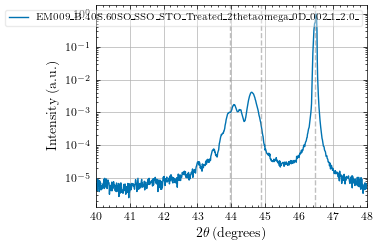

In [5]:
export_data = True
fig1 = ttw_plot_same( single_dat, x_lim=[40,48], norm_plot = True, linear_subtraction=False, log_plot=True, med_filt=0 )

# if export_data == True:
#     fig1.savefig(single_dat[0].folder_path.joinpath(f'{powerpoint_string}_single_ttw.{fig_format}'), dpi=600, bbox_inches='tight', transparent=plot_transparency)

## XRD Fitting: To Do List
- Use STO roughness parameter to add a roughness to the z=0 layer so that you have a small offset in the z starting position from zero (this will then add to the top surface roughness which we separately fit)
- Change to work with Q.r
    - each lattice point should have x,y,z coordinates
    - instead we initialise our crystal by slightly displacing these with tilt, roughness etc
    - now including correlation (e.g. tilt will be for a certain grain x,y size and through z)
    - then we calculate Q.r for these r positions
    - done for array of Q to give Qx, Qz - RSM
    - Can fit moscaicity from w rocking in RSM preferentially
    - Get improved fit parameters by iterating through

## Multi-Peak Fitting: Overlapping BSO + SSO

This section demonstrates simultaneous fitting of multiple overlapping film peaks (e.g., BSO and SSO) with the STO substrate background.

**Key Differences from Single-Peak Fitting:**
- Each peak has its own 9 parameters (lattice, thickness, roughness, etc.)
- All peaks are simulated and summed together before comparison to experiment
- The optimizer adjusts all parameters simultaneously to minimize total residual
- Enables proper deconvolution of overlapping contributions

In [ ]:
# ========== Fit Substrate (STO) Peak ==========
# Purpose: Determine instrumental broadening and attenuation length accurately
# Range: 46.0 - 48.0 degrees (STO 002 peak)


print('experimental_data=',single_dat) # chosen experimental data for fitting
exp_data = single_dat[0]
wavelength = exp_data.wavelength


# --- 1. STO Fitting Configuration ---
fit_range_STO = (46.0, 47.2)
# OPTIMIZATION: Reduced grid size for Substrate. 
# STO is uniform, so we don't need many columns to average out spatial variation.
nx_fit_STO, ny_fit_STO = 1, 1 
peak_search_range_STO = (46.0, 48.0)

# Find STO peak
peak_pos_STO, peak_int_STO = find_peak(exp_data, peak_search_range_STO)
print(f"Found STO peak at {peak_pos_STO:.3f}° with intensity {peak_int_STO:.0f}")

# Known STO Parameters
c_STO_lit = 3.905 # Å (Literature value for SrTiO3)

# --- 2. Bounds for STO (Substrate) ---
# Note on Thickness: We use 1500 nm. 
# Real thickness is 500,000 nm, but simulating >1 million layers causes memory crashes.
# 1500 nm is sufficient to approximate a "thick" crystal (Laue fringes merge).

bounds_STO = [
    (c_STO_lit * 0.998, c_STO_lit * 1.002), # 1. c_start: Fixed to 3.905 Å (Interface)
    (c_STO_lit * 0.998, c_STO_lit * 1.002), # 2. c_end: Fixed to 3.905 Å (Surface)
    (6000.0, 6000.0), # 3. Thickness: Fixed to 1500 nm (Computational Limit)
    (0.0, 0.05),     # 4. Spatial Var: Lattice variation (%) - Low for single crystal
    (0.0, 0.6),     # 5. Roughness: Surface roughness (nm)
    (0.0, 0.5),     # 6. Mosaicity: Crystallite tilt (deg)
    (1.0, 10.0),    # 7. Relaxation: Strain relaxation length (layers) - Irrelevant for constant c
    (10000, 50000),  # 8. Attenuation: X-ray penetration depth (nm) - FITTING TARGET
    (0.01, 0.1)     # 9. Instrumental: Machine broadening (deg) - FITTING TARGET
]

p0_STO = [3.9068, 3.9068, 6000.00, 0.0151, 0.2292, 0.1910, 5.63, 19466, 0.0690 ]#np.mean(bounds_STO, axis=1)


# --- 3. Optimization Settings ---
# For STO: Can use faster local-only search since it's a simple peak
use_global_STO = False  # Set True for global search (slower, more robust)
de_maxiter_STO = 30     # DE iterations (if use_global_STO=True)
de_popsize_STO = 10     # DE population multiplier (if use_global_STO=True)
powell_tol_STO = 0.01   # Powell tolerance (lower = more precise)
powell_maxiter_STO = 100  # Powell max iterations

# --- 4. Run STO Optimization ---
print("\n--- Fitting STO Substrate ---")
res_STO = run_xrd_fitting(exp_data, peak_int_STO, wavelength,
                          fit_range=fit_range_STO,
                          nx_fit=nx_fit_STO, ny_fit=ny_fit_STO,
                          use_log_residual=True,
                          p0=p0_STO, bounds=bounds_STO,
                          use_global_search=use_global_STO,
                          de_maxiter=de_maxiter_STO,
                          de_popsize=de_popsize_STO,
                          tol=powell_tol_STO, 
                          maxiter=powell_maxiter_STO)

p_STO = res_STO.x
print("\n" + "="*70)
print("STO Best Fit Parameters:")
print("="*70)
print(f"  c_start:       {p_STO[0]:.4f} Å (bounds: [{bounds_STO[0][0]:.4f}, {bounds_STO[0][1]:.4f}])")
print(f"  c_end:         {p_STO[1]:.4f} Å (bounds: [{bounds_STO[1][0]:.4f}, {bounds_STO[1][1]:.4f}])")
print(f"  Thickness:     {p_STO[2]:.2f} nm (bounds: [{bounds_STO[2][0]:.2f}, {bounds_STO[2][1]:.2f}])")
print(f"  Spatial Var:   {p_STO[3]:.4f} % (bounds: [{bounds_STO[3][0]:.4f}, {bounds_STO[3][1]:.4f}])")
print(f"  Roughness:     {p_STO[4]:.4f} nm (bounds: [{bounds_STO[4][0]:.4f}, {bounds_STO[4][1]:.4f}])")
print(f"  Mosaicity:     {p_STO[5]:.4f} deg (bounds: [{bounds_STO[5][0]:.4f}, {bounds_STO[5][1]:.4f}])")
print(f"  Relax Length:  {p_STO[6]:.2f} layers (bounds: [{bounds_STO[6][0]:.2f}, {bounds_STO[6][1]:.2f}])")
print(f"  Attenuation:   {p_STO[7]:.0f} nm (bounds: [{bounds_STO[7][0]:.0f}, {bounds_STO[7][1]:.0f}])")
print(f"  Instrumental:  {p_STO[8]:.4f} deg (bounds: [{bounds_STO[8][0]:.4f}, {bounds_STO[8][1]:.4f}])")
print("="*70)

# Extract fitted parameters for later use in film fitting
atten_STO = p_STO[7]
instr_STO = p_STO[8]



experimental_data= [<ttw.ttw object at 0x129bd3770>]
Found STO peak at 46.495° with intensity 4438613

--- Fitting STO Substrate ---
Setting up optimization in range (46.0, 47.2) with grid 1x1...
Optimization mode: Local (Powell only)
  Settings: film_scale=1.0000, background=None
  Powell params: tol=0.01, maxiter=100

=== Local Optimization (Powell only) ===
Eval 1: Residual = 9.130226
Eval 1: Residual = 9.130226
Eval 2: Residual = 13.982012
Eval 2: Residual = 13.982012
Eval 3: Residual = 7.321055
Eval 3: Residual = 7.321055
Eval 4: Residual = 10.917136
Eval 4: Residual = 10.917136
Eval 5: Residual = 11.612855
Eval 5: Residual = 11.612855
Eval 6: Residual = 16.877240
Eval 6: Residual = 16.877240
Eval 7: Residual = 13.386969
Eval 7: Residual = 13.386969
Eval 8: Residual = 6.909377
Eval 8: Residual = 6.909377
Eval 9: Residual = 6.173870
Eval 9: Residual = 6.173870
Eval 10: Residual = 22.690980
Eval 10: Residual = 22.690980
Eval 11: Residual = 6.169636
Eval 11: Residual = 6.169636
Eval 


Generating STO fit plot...


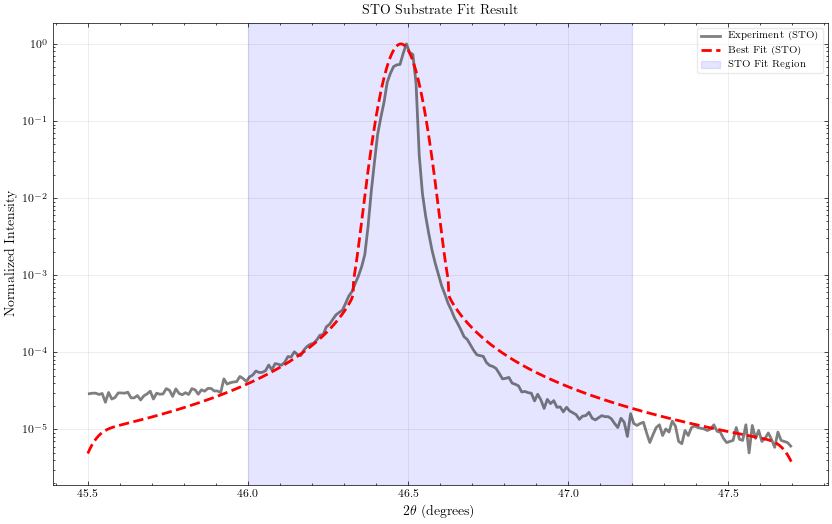


STO Best Fit Parameters:
  c_start:       3.9032 Å (bounds: [3.8972, 3.9128])
  c_end:         3.9068 Å (bounds: [3.8972, 3.9128])
  Thickness:     6000.00 nm (bounds: [6000.00, 6000.00])
  Spatial Var:   0.0266 % (bounds: [0.0000, 0.0500])
  Roughness:     0.5125 nm (bounds: [0.0000, 0.6000])
  Mosaicity:     0.3188 deg (bounds: [0.0000, 0.5000])
  Relax Length:  4.44 layers (bounds: [1.00, 10.00])
  Attenuation:   40557 nm (bounds: [10000, 50000])
  Instrumental:  0.0869 deg (bounds: [0.0100, 0.1000])


In [7]:
# --- 4. Plot STO Fit Result ---
print("\nGenerating STO fit plot...")
# Re-run simulation with best parameters
nz_STO_best = int((p_STO[2] * 10) / p_STO[1])
lat_arr_STO, h_map_STO, t_arr_STO = create_crystal_system(
    nx_fit_STO, ny_fit_STO, nz_STO_best,
    p_STO[1], [p_STO[0], p_STO[1]],
    mode='full', gradient_type='exponential',
    spatial_var_percent=p_STO[3], roughness_layers=(p_STO[4]*10)/p_STO[1],
    mosaicity_fwhm=p_STO[5], relaxation_length=p_STO[6]
)

# Calculate STO signal
x_exp = exp_data.ttw_df[0]['Angle'].values
y_exp_norm = exp_data.ttw_df[0]['Intensity'].values / peak_int_STO

tt_best_STO, int_best_STO = calculate_xrd_vectorized(
    lat_arr_STO, h_map_STO, t_arr_STO,
    two_theta_range=(fit_range_STO[0]-0.5, fit_range_STO[1]+0.5), # Plot around fit range
    wavelength=wavelength,
    attenuation_length_nm=p_STO[7],
    instrumental_broadening=p_STO[8],
    n_points=1000,
    normalize=True
)

plt.figure(figsize=(10, 6))
# Plot experimental data in the relevant range
mask_plot = (x_exp >= fit_range_STO[0]-0.5) & (x_exp <= fit_range_STO[1]+0.5)
plt.plot(x_exp[mask_plot], y_exp_norm[mask_plot], 'k-', label='Experiment (STO)', alpha=0.5, linewidth=2)
plt.plot(tt_best_STO, int_best_STO, 'r--', label='Best Fit (STO)', linewidth=2)

plt.axvspan(fit_range_STO[0], fit_range_STO[1], color='blue', alpha=0.1, label='STO Fit Region')

plt.xlabel(r'$2\theta$ (degrees)')
plt.ylabel('Normalized Intensity')
plt.title('STO Substrate Fit Result')
plt.legend()
plt.yscale('log')
#plt.ylim(1e-3, 1.5)
plt.grid(True, alpha=0.3)
plt.show()



print("\n" + "="*70)
print("STO Best Fit Parameters:")
print("="*70)
print(f"  c_start:       {p_STO[0]:.4f} Å (bounds: [{bounds_STO[0][0]:.4f}, {bounds_STO[0][1]:.4f}])")
print(f"  c_end:         {p_STO[1]:.4f} Å (bounds: [{bounds_STO[1][0]:.4f}, {bounds_STO[1][1]:.4f}])")
print(f"  Thickness:     {p_STO[2]:.2f} nm (bounds: [{bounds_STO[2][0]:.2f}, {bounds_STO[2][1]:.2f}])")
print(f"  Spatial Var:   {p_STO[3]:.4f} % (bounds: [{bounds_STO[3][0]:.4f}, {bounds_STO[3][1]:.4f}])")
print(f"  Roughness:     {p_STO[4]:.4f} nm (bounds: [{bounds_STO[4][0]:.4f}, {bounds_STO[4][1]:.4f}])")
print(f"  Mosaicity:     {p_STO[5]:.4f} deg (bounds: [{bounds_STO[5][0]:.4f}, {bounds_STO[5][1]:.4f}])")
print(f"  Relax Length:  {p_STO[6]:.2f} layers (bounds: [{bounds_STO[6][0]:.2f}, {bounds_STO[6][1]:.2f}])")
print(f"  Attenuation:   {p_STO[7]:.0f} nm (bounds: [{bounds_STO[7][0]:.0f}, {bounds_STO[7][1]:.0f}])")
print(f"  Instrumental:  {p_STO[8]:.4f} deg (bounds: [{bounds_STO[8][0]:.4f}, {bounds_STO[8][1]:.4f}])")
print("="*70)

In [8]:
# ========== Generate STO Background for Multi-Peak Fitting ==========
# Purpose: Create full STO signal over experimental range for use as background

print("\nGenerating STO background over full experimental range...")

# Calculate STO signal over the entire experimental range
tt_full, int_full_STO = calculate_xrd_vectorized(
    lat_arr_STO, h_map_STO, t_arr_STO,
    two_theta_range=(x_exp.min(), x_exp.max()),  # Full experimental range
    wavelength=wavelength,
    attenuation_length_nm=p_STO[7],
    instrumental_broadening=p_STO[8],
    n_points=3000,  # High resolution for interpolation
    normalize=True
)

# Interpolate to experimental grid for use as background in multi-peak fitting
int_bg_STO_full = np.interp(x_exp, tt_full, int_full_STO)

print(f"Generated STO background:")
print(f"  Angular range: {x_exp.min():.2f}° - {x_exp.max():.2f}°")
print(f"  Number of points: {len(x_exp)}")
print(f"  Background intensity range: {int_bg_STO_full.min():.2e} - {int_bg_STO_full.max():.2e}")
print("Ready for multi-peak fitting!")


Generating STO background over full experimental range...
Generated STO background:
  Angular range: 40.01° - 47.99°
  Number of points: 800
  Background intensity range: 1.80e-07 - 9.98e-01
Ready for multi-peak fitting!
Generated STO background:
  Angular range: 40.01° - 47.99°
  Number of points: 800
  Background intensity range: 1.80e-07 - 9.98e-01
Ready for multi-peak fitting!


In [9]:
# ========== Multi-Peak Setup: Find Both BSO and SSO Peaks ==========
from ttw_models import run_multi_peak_xrd_fitting

# Use the same experimental data and STO background as before
# exp_data and int_bg_STO_full should already be defined from previous cells

# Define the two peaks we want to fit
peak_labels = ['BSO', 'SSO']

# Search for each peak in its expected range
peak_search_range_BSO_multi = (43.5, 44.5)  # BSO expected around 44°
peak_search_range_SSO_multi = (44.5, 45.0)  # SSO expected around 42.5°

# Find peak positions and intensities
peak_pos_BSO_multi, peak_int_BSO_multi = find_peak(exp_data, peak_search_range_BSO_multi)
peak_pos_SSO_multi, peak_int_SSO_multi = find_peak(exp_data, peak_search_range_SSO_multi)

print(f"BSO Peak: {peak_pos_BSO_multi:.3f}° with intensity {peak_int_BSO_multi:.0f}")
print(f"SSO Peak: {peak_pos_SSO_multi:.3f}° with intensity {peak_int_SSO_multi:.0f}")

# Calculate initial lattice parameter guesses
theta_rad_BSO_multi = np.radians(peak_pos_BSO_multi / 2)
c_guess_BSO_multi = (wavelength / (2 * np.sin(theta_rad_BSO_multi))) * 2

theta_rad_SSO_multi = np.radians(peak_pos_SSO_multi / 2)
c_guess_SSO_multi = (wavelength / (2 * np.sin(theta_rad_SSO_multi))) * 2

print(f"\nEstimated lattice parameters:")
print(f"  BSO: c = {c_guess_BSO_multi:.4f} Å")
print(f"  SSO: c = {c_guess_SSO_multi:.4f} Å")

# Peak intensities for scaling (normalized to STO)
peak_intensities = [peak_int_BSO_multi, peak_int_SSO_multi]

# Calculate film scale factors
film_scale_BSO_multi = peak_int_BSO_multi / peak_int_STO
film_scale_SSO_multi = peak_int_SSO_multi / peak_int_STO
print(f"\nFilm/Substrate intensity ratios:")
print(f"  BSO/STO: {film_scale_BSO_multi:.4f}")
print(f"  SSO/STO: {film_scale_SSO_multi:.4f}")

BSO Peak: 44.495° with intensity 8800
SSO Peak: 44.595° with intensity 18142

Estimated lattice parameters:
  BSO: c = 4.0691 Å
  SSO: c = 4.0604 Å

Film/Substrate intensity ratios:
  BSO/STO: 0.0020
  SSO/STO: 0.0041


In [10]:
# ========== Multi-Peak Configuration: Bounds and Grid Sizes ==========

# Fitting ranges for each peak (can overlap!)
fit_ranges_multi = [
    (42, 44.5),  # BSO range
    (44.5, 46)   # SSO range
]

# Grid sizes for each peak simulation
nx_fits_multi = [8, 8]  # BSO, SSO
ny_fits_multi = [8, 8]

# --- BSO Bounds ---
bounds_BSO_multi = [
    (c_guess_BSO_multi * 0.96, c_guess_BSO_multi * 1.04),  # 1. c_start (Interface)
    (c_guess_BSO_multi * 0.96, c_guess_BSO_multi * 1.04),  # 2. c_end (Surface)
    (18, 25),     # 3. Thickness (nm)
    (0.0, 1.0),       # 4. Spatial Var (%)
    (0.0, 1.0),       # 5. Roughness (nm)
    (0.0, 1.0),       # 6. Mosaicity (deg)
    (1.0, 50.0),      # 7. Relaxation Length (layers)
    (atten_STO * 0.97, atten_STO * 1.03),  # 8. Attenuation (nm) - constrained by STO
    (instr_STO * 0.97, instr_STO * 1.03)   # 9. Instrumental (deg) - constrained by STO
]

# --- SSO Bounds ---
bounds_SSO_multi = [
    (c_guess_SSO_multi * 0.96, c_guess_SSO_multi * 1.04),  # 1. c_start (Interface)
    (c_guess_SSO_multi * 0.96, c_guess_SSO_multi * 1.04),  # 2. c_end (Surface)
    (40, 46),     # 3. Thickness (nm)
    (0.0, 1.0),       # 4. Spatial Var (%)
    (0.0, 1.0),       # 5. Roughness (nm)
    (0.0, 1.0),       # 6. Mosaicity (deg)
    (1.0, 50.0),      # 7. Relaxation Length (layers)
    (atten_STO * 0.97, atten_STO * 1.03),  # 8. Attenuation (nm) - shared with BSO
    (instr_STO * 0.97, instr_STO * 1.03)   # 9. Instrumental (deg) - shared with BSO
]

bounds_list_multi = [bounds_BSO_multi, bounds_SSO_multi]

# Initial guesses (center of bounds)
p0_BSO_multi = np.mean(bounds_BSO_multi, axis=1)
p0_SSO_multi = np.mean(bounds_SSO_multi, axis=1)
p0_list_multi = [p0_BSO_multi, p0_SSO_multi]

print("Multi-peak fitting configuration:")
print(f"  Number of peaks: {len(peak_labels)}")
print(f"  Total parameters: {len(peak_labels) * 9}")
print(f"  Fitting ranges: {fit_ranges_multi}")
print(f"  Grid sizes: {list(zip(nx_fits_multi, ny_fits_multi))}")

Multi-peak fitting configuration:
  Number of peaks: 2
  Total parameters: 18
  Fitting ranges: [(42, 44.5), (44.5, 46)]
  Grid sizes: [(8, 8), (8, 8)]


In [ ]:
# ========== Run Multi-Peak Optimization ==========

# Optimization settings
use_global_multi = True   # Use global search for robustness
de_maxiter_multi = 40     # DE iterations (will take longer with multiple peaks!)
de_popsize_multi = 10     # DE population multiplier
powell_tol_multi = 0.005  # Powell tolerance
powell_maxiter_multi = 300  # Powell max iterations

print("\n" + "="*70)
print("Starting Multi-Peak Fitting (BSO + SSO + STO Background)")
print("="*70)
print("\nWARNING: This will take significantly longer than single-peak fitting!")
print(f"Expected time: ~10-20 minutes with global search")
print("Consider reducing de_maxiter_multi or de_popsize_multi for faster results.\n")

# Run the multi-peak fitting
results_multi = run_multi_peak_xrd_fitting(
    exp_data, 
    peak_labels=peak_labels,
    peak_intensities=peak_intensities,
    wavelength=wavelength,
    fit_ranges=fit_ranges_multi,
    nx_fits=nx_fits_multi,
    ny_fits=ny_fits_multi,
    use_log_residual=True,
    p0_list=p0_list_multi,
    bounds_list=bounds_list_multi,
    use_global_search=use_global_multi,
    de_maxiter=de_maxiter_multi,
    de_popsize=de_popsize_multi,
    tol=powell_tol_multi,
    maxiter=powell_maxiter_multi,
    background_intensity=int_bg_STO_full,  # Add STO background
    normalization_peak_intensity=peak_int_STO
)

# Extract optimized parameters
params_BSO_opt = results_multi['params_per_peak'][0]
params_SSO_opt = results_multi['params_per_peak'][1]

print("\n" + "="*70)
print("BSO (Peak 1) Best Fit Parameters:")
print("="*70)
print(f"  c_start (Interface):  {params_BSO_opt[0]:.4f} Å (bounds: [{bounds_BSO_multi[0][0]:.4f}, {bounds_BSO_multi[0][1]:.4f}])")
print(f"  c_end (Surface):      {params_BSO_opt[1]:.4f} Å (bounds: [{bounds_BSO_multi[1][0]:.4f}, {bounds_BSO_multi[1][1]:.4f}])")
print(f"  Thickness:            {params_BSO_opt[2]:.2f} nm (bounds: [{bounds_BSO_multi[2][0]:.2f}, {bounds_BSO_multi[2][1]:.2f}])")
print(f"  Spatial Var:          {params_BSO_opt[3]:.4f} % (bounds: [{bounds_BSO_multi[3][0]:.4f}, {bounds_BSO_multi[3][1]:.4f}])")
print(f"  Roughness:            {params_BSO_opt[4]:.4f} nm (bounds: [{bounds_BSO_multi[4][0]:.4f}, {bounds_BSO_multi[4][1]:.4f}])")
print(f"  Mosaicity:            {params_BSO_opt[5]:.4f} deg (bounds: [{bounds_BSO_multi[5][0]:.4f}, {bounds_BSO_multi[5][1]:.4f}])")
print(f"  Relax Length:         {params_BSO_opt[6]:.2f} layers (bounds: [{bounds_BSO_multi[6][0]:.2f}, {bounds_BSO_multi[6][1]:.2f}])")
print(f"  Attenuation:          {params_BSO_opt[7]:.0f} nm (bounds: [{bounds_BSO_multi[7][0]:.0f}, {bounds_BSO_multi[7][1]:.0f}])")
print(f"  Instrumental:         {params_BSO_opt[8]:.4f} deg (bounds: [{bounds_BSO_multi[8][0]:.4f}, {bounds_BSO_multi[8][1]:.4f}])")

print("\n" + "="*70)
print("SSO (Peak 2) Best Fit Parameters:")
print("="*70)
print(f"  c_start (Interface):  {params_SSO_opt[0]:.4f} Å (bounds: [{bounds_SSO_multi[0][0]:.4f}, {bounds_SSO_multi[0][1]:.4f}])")
print(f"  c_end (Surface):      {params_SSO_opt[1]:.4f} Å (bounds: [{bounds_SSO_multi[1][0]:.4f}, {bounds_SSO_multi[1][1]:.4f}])")
print(f"  Thickness:            {params_SSO_opt[2]:.2f} nm (bounds: [{bounds_SSO_multi[2][0]:.2f}, {bounds_SSO_multi[2][1]:.2f}])")
print(f"  Spatial Var:          {params_SSO_opt[3]:.4f} % (bounds: [{bounds_SSO_multi[3][0]:.4f}, {bounds_SSO_multi[3][1]:.4f}])")
print(f"  Roughness:            {params_SSO_opt[4]:.4f} nm (bounds: [{bounds_SSO_multi[4][0]:.4f}, {bounds_SSO_multi[4][1]:.4f}])")
print(f"  Mosaicity:            {params_SSO_opt[5]:.4f} deg (bounds: [{bounds_SSO_multi[5][0]:.4f}, {bounds_SSO_multi[5][1]:.4f}])")
print(f"  Relax Length:         {params_SSO_opt[6]:.2f} layers (bounds: [{bounds_SSO_multi[6][0]:.2f}, {bounds_SSO_multi[6][1]:.2f}])")
print(f"  Attenuation:          {params_SSO_opt[7]:.0f} nm (bounds: [{bounds_SSO_multi[7][0]:.0f}, {bounds_SSO_multi[7][1]:.0f}])")
print(f"  Instrumental:         {params_SSO_opt[8]:.4f} deg (bounds: [{bounds_SSO_multi[8][0]:.4f}, {bounds_SSO_multi[8][1]:.4f}])")
print("="*70)


Starting Multi-Peak Fitting (BSO + SSO + STO Background)

Expected time: ~10-20 minutes with global search
Consider reducing de_maxiter_multi or de_popsize_multi for faster results.


Multi-Peak Fitting: 2 peaks (BSO, SSO)
Overall fitting range: (42, 46)
  BSO: (42, 44.5), grid 8x8
  SSO: (44.5, 46), grid 8x8
Optimization mode: Global (DE) + Local (Powell)
  Background: Enabled

Film scale factors: ['0.0020', '0.0041']

Total parameters to fit: 18 (9 per peak × 2 peaks)

=== Starting Optimization ===
Stage 1: Differential Evolution (exploring parameter space)
  maxiter=40, popsize=10
  Iteration 50: Residual = 712.404076
  Iteration 50: Residual = 712.404076
  Iteration 100: Residual = 823.714342
  Iteration 100: Residual = 823.714342
  Iteration 150: Residual = 1171.261593
  Iteration 150: Residual = 1171.261593
  Iteration 200: Residual = 951.520561
  Iteration 200: Residual = 951.520561
  Iteration 250: Residual = 330.074898
  Iteration 250: Residual = 330.074898
  Iteration 300: R

In [ ]:
# ========== Plot Multi-Peak Fitting Results ==========

print("\nGenerating multi-peak fit plot...")

# Simulate each peak individually with optimized parameters
simulations = []

for i, (label, params) in enumerate(zip(peak_labels, [params_BSO_opt, params_SSO_opt])):
    # Unpack parameters
    c_start, c_end, t_nm, s_var, r_nm, mos, rel_len, att_len, instr = params
    
    # Derived parameters
    nz_fit = int((t_nm * 10) / c_end)
    r_layers = (r_nm * 10) / c_end
    
    # Generate system
    lat_arr, h_map, t_arr = create_crystal_system(
        nx_fits_multi[i], ny_fits_multi[i], nz_fit,
        c_end,
        [c_start, c_end],
        mode='full',
        gradient_type='exponential',
        spatial_var_percent=s_var,
        roughness_layers=r_layers,
        mosaicity_fwhm=mos,
        relaxation_length=rel_len
    )
    
    # Calculate XRD over full experimental range
    tt_sim, int_sim = calculate_xrd_vectorized(
        lat_arr, h_map, t_arr,
        two_theta_range=(x_exp.min(), x_exp.max()),
        wavelength=wavelength,
        attenuation_length_nm=att_len,
        instrumental_broadening=instr,
        n_points=3000,
        normalize=True
    )
    
    # Scale to experimental intensity ratio
    int_sim = int_sim * results_multi['film_scales'][i]
    
    simulations.append({
        'label': label,
        'two_theta': tt_sim,
        'intensity': int_sim
    })

# Calculate total signal: BSO + SSO + STO background
int_BSO_sim = np.interp(x_exp, simulations[0]['two_theta'], simulations[0]['intensity'])
int_SSO_sim = np.interp(x_exp, simulations[1]['two_theta'], simulations[1]['intensity'])
int_bg_STO_exp_range = np.interp(x_exp, tt_full, int_full_STO)
int_total_multi = int_BSO_sim + int_SSO_sim + int_bg_STO_exp_range

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), 
                                 gridspec_kw={'height_ratios': [3, 1]})

# Main plot
ax1.plot(x_exp, y_exp_norm, 'k-', label='Experiment', linewidth=2.5, alpha=0.6, zorder=10)
ax1.plot(x_exp, int_total_multi, 'r-', label='Total Fit (BSO+SSO+STO)', linewidth=2, alpha=0.9)
ax1.plot(x_exp, int_BSO_sim, 'b--', label='BSO Component', linewidth=1.5, alpha=0.7)
ax1.plot(x_exp, int_SSO_sim, 'g--', label='SSO Component', linewidth=1.5, alpha=0.7)
ax1.plot(x_exp, int_bg_STO_exp_range, 'm:', label='STO Background', linewidth=1.5, alpha=0.7)

# Mark fitting regions
ax1.axvspan(fit_ranges_multi[0][0], fit_ranges_multi[0][1], color='blue', alpha=0.05, label='BSO Fit Region')
ax1.axvspan(fit_ranges_multi[1][0], fit_ranges_multi[1][1], color='green', alpha=0.05, label='SSO Fit Region')

ax1.set_ylabel('Normalized Intensity (STO=1)', fontsize=12)
ax1.set_title('Multi-Peak Fit: BSO + SSO + STO Background', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.set_yscale('log')
ax1.set_ylim(1e-4, 2)
ax1.grid(True, alpha=0.3)
ax1.set_xticklabels([])  # Remove x labels from top plot

# Residual plot
residual = y_exp_norm - int_total_multi
ax2.plot(x_exp, residual, 'k-', linewidth=1, alpha=0.7)
ax2.axhline(0, color='red', linestyle='--', linewidth=1)
ax2.axvspan(fit_ranges_multi[0][0], fit_ranges_multi[0][1], color='blue', alpha=0.05)
ax2.axvspan(fit_ranges_multi[1][0], fit_ranges_multi[1][1], color='green', alpha=0.05)
ax2.set_xlabel(r'$2\theta$ (degrees)', fontsize=12)
ax2.set_ylabel('Residual', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPlot complete!")

### Understanding Multi-Peak Fitting

**How It Works:**

1. **Parameter Space**: Each peak has 9 parameters → Total = 18 parameters for BSO+SSO
   - BSO: [c_start, c_end, thickness, spatial_var, roughness, mosaicity, relax_len, atten, instr]
   - SSO: [c_start, c_end, thickness, spatial_var, roughness, mosaicity, relax_len, atten, instr]

2. **Objective Function**: 
   ```
   Simulated_Total = BSO_sim * scale_BSO + SSO_sim * scale_SSO + STO_background
   Residual = Σ(log(Experiment) - log(Simulated_Total))²
   ```

3. **Optimization Strategy**:
   - **Stage 1 (DE)**: Population-based search explores all 18D parameter space simultaneously
   - **Stage 2 (Powell)**: Refines the solution to high precision
   - Both peaks are **coupled** through the shared experimental data

**Key Advantages:**
- Proper deconvolution of overlapping peaks
- Shared instrumental parameters (attenuation, broadening) ensure physical consistency
- Accounts for interference between peaks in overlapping regions

**Tips for Success:**
- Set reasonable bounds based on single-peak fits
- Consider constraining attenuation/instrumental to be the same for both peaks
- Start with wider fitting ranges that capture both peaks
- Reduce `de_maxiter` or `de_popsize` for faster (but potentially less accurate) results

### Extending to More Peaks (N-Peak Fitting)

The `run_multi_peak_xrd_fitting()` function is fully generalized and can handle any number of peaks:

```python
# Example: Fitting 3 peaks (BSO, SSO, LAO)
peak_labels = ['BSO', 'SSO', 'LAO']
peak_intensities = [peak_int_BSO, peak_int_SSO, peak_int_LAO]
fit_ranges_multi = [(43.0, 45.5), (41.5, 43.5), (40.0, 42.0)]
nx_fits_multi = [8, 8, 8]
ny_fits_multi = [8, 8, 8]
bounds_list_multi = [bounds_BSO, bounds_SSO, bounds_LAO]
p0_list_multi = [p0_BSO, p0_SSO, p0_LAO]

# Run with same function call
results_multi = run_multi_peak_xrd_fitting(
    exp_data, peak_labels, peak_intensities, wavelength,
    fit_ranges_multi, nx_fits_multi, ny_fits_multi,
    p0_list=p0_list_multi, bounds_list=bounds_list_multi,
    use_global_search=True, ...
)
```

**Important Notes:**
- Each additional peak adds 9 parameters → optimization time scales significantly
- With 3 peaks (27 params), consider reducing DE iterations or using tighter bounds
- Computational cost: ~O(N²) due to increased parameter space and simulation overhead